# A guided tour of cuPeriod

**[cuPeriod](https://github.com/tjayasinghe/cuPeriod)** finds the periods of variable
stars and transiting planets. This notebook walks through the main ideas on **real
light curves** — plus one simulated star at the end — and shows, for each kind of object,
how to pick a method, read the **periodogram**, and check the answer by **phase-folding**.

### The three pictures we'll draw for every star
1. **Raw light curve** — brightness vs. time. Periodic, but the period is hidden by the
   irregular sampling.
2. **Periodogram** — cuPeriod evaluates a statistic on a grid of trial periods; a tall
   (or, for some methods, deep) peak marks the best period.
3. **Phased light curve** — fold the times on the best period (`phase = (t / P) mod 1`).
   At the *right* period the scattered points collapse into the star's repeating shape.

### The data
- **Variable stars** — 6 real [ASAS-SN](https://asas-sn.osu.edu/) *g*-band light curves
  bundled in `data/asassn_examples.parquet`, each with its literature (VSX) period.
- **Exoplanet** — a confirmed *Kepler* planet host (KIC 7532973) in
  `data/kepler_KIC7532973.csv`, fetched once with
  [lightkurve](https://docs.lightkurve.org/).
- **Sparse six-band star (§7)** — the one *synthetic* object, simulated inline on a
  Rubin/LSST-like cadence: to watch a period search *fail* we have to know the answer.

> **Run it:** `pip install cuperiod matplotlib pandas pyarrow` and run the notebook from
> the `examples/` folder. With an NVIDIA GPU, add `pip install "cuperiod[gpu]"` and the
> same code runs on the GPU automatically.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")  # keep the tutorial output clean

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cuperiod as cup

print("cuPeriod", cup.__version__)
print("methods:", [m.name for m in cup.list_methods()])

# Resolve the bundled data whether the notebook runs from examples/ or the repo root.
DATA = Path("data") if Path("data/asassn_examples.parquet").exists() else Path("examples/data")

# The bundled example light curves (ASAS-SN g-band, with VSX literature periods).
STARS = pd.read_parquet(DATA / "asassn_examples.parquet").set_index("asas_sn_id")

def star(asas_sn_id):
    "Return (time, mag, mag_err, vsx_type, vsx_period) for a bundled star."
    r = STARS.loc[asas_sn_id]
    return (np.asarray(r.jd, float), np.asarray(r.mag, float),
            np.asarray(r.mag_err, float), r.vsx_type, float(r.vsx_period))

cuPeriod 1.2.0
methods: ['BLS', 'CE', 'GLS', 'MHAOV', 'PDM', 'STRINGLENGTH', 'SUPERSMOOTHER', 'TLS']


In [2]:
def show(t, y, pg, *, title, flux=False, t0=None, window=None, period=None):
    "Draw the raw light curve, the periodogram, and the phased light curve."
    P = pg.best_period() if period is None else period
    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13.5, 3.4))

    a1.scatter(t - t.min(), y, s=5, alpha=.5, color="#1f77b4", lw=0)
    if not flux: a1.invert_yaxis()             # magnitudes: brighter is up
    a1.set(xlabel="time (days)", ylabel="flux" if flux else "magnitude",
           title=f"{title}\nraw light curve  (n = {t.size})")

    a2.plot(pg.period, pg.power, lw=.8, color="#4c72b0")
    a2.axvline(P, color="C1", ls="--", lw=1.2, label=f"best P = {P:.6g} d")
    a2.set(xscale="log", xlabel="trial period (days)",
           ylabel=f"{pg.method} {'SDE' if pg.method=='TLS' else 'power'}",
           title=f"periodogram  (backend: {pg.backend})")
    a2.legend(loc="best", fontsize=8)

    ph = ((t - (t.min() if t0 is None else t0)) / P) % 1.0
    if window:                                  # center a transit/eclipse on phase 0
        ph = np.where(ph > 0.5, ph - 1.0, ph)
    a3.scatter(ph, y, s=5, alpha=.4, color="#55a868", lw=0)
    if not flux: a3.invert_yaxis()
    a3.set(xlabel="phase", ylabel="flux" if flux else "magnitude",
           title=f"folded on {P:.6g} d")
    if window: a3.set_xlim(-window, window)
    fig.tight_layout(); plt.show()

## 1. A pulsating star — generalized Lomb–Scargle (GLS)

**GLS** is the workhorse: it fits a floating-mean sinusoid at each trial frequency and
reports how much variance it explains. It's the right first thing to try for any smooth,
roughly periodic variable.

Here's a **classical Cepheid** — a pulsating supergiant (the cosmic distance ladder's
standard candle). Note how the raw curve looks like noise, the periodogram has one sharp
spike, and folding on that period reveals the Cepheid's characteristic saw-toothed
pulsation.

GLS best period = 17.10975 d   (VSX: 17.09780 d, type DCEP)


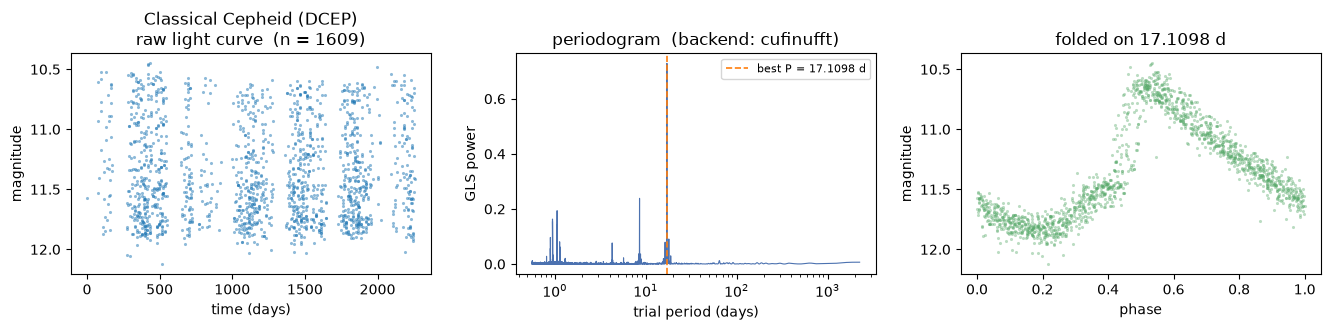

In [3]:
t, m, e, vtype, P_vsx = star(661425373355)
pg = cup.periodogram((t, m, e), "GLS")
print(f"GLS best period = {pg.best_period():.5f} d   (VSX: {P_vsx:.5f} d, type {vtype})")
show(t, m, pg, title=f"Classical Cepheid ({vtype})")

## 2. Sharp, non-sinusoidal pulsations — MHAOV

An **RR Lyrae** (RRab) star has a steep rise and a slow decline — far from a single
sinusoid. **MHAOV** (multiharmonic Analysis of Variance) fits a trigonometric polynomial of
several harmonics, so it captures that sharp shape.

RR Lyrae pulsate in roughly **0.3–1 day**, so we restrict the search to that range. That's
good practice in general, and here it also sidesteps the **1-day alias** and the
integer-period **subharmonics** that plague ground-based data — without the bound, the
strongest peak for this star is at *twice* the true period.

MHAOV best period = 0.70675 d   (VSX: 0.70676 d, type RRAB)


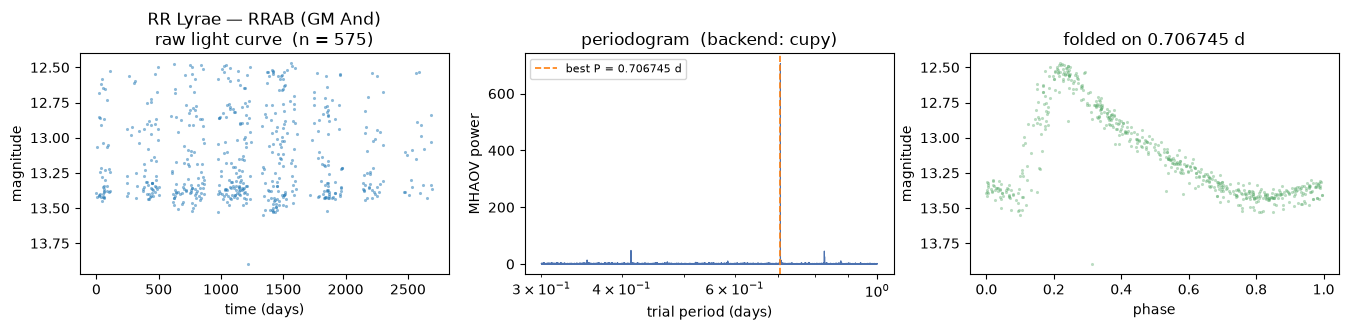

In [4]:
t, m, e, vtype, P_vsx = star(8590948612)   # GM And, a clean RRab
pg = cup.periodogram((t, m, e), "MHAOV",
                     settings=cup.MHAOVSettings(n_harmonics=4,
                                                minimum_frequency=1.0,         # period < 1 day
                                                maximum_frequency=1.0 / 0.3))  # period > 0.3 day
print(f"MHAOV best period = {pg.best_period():.5f} d   (VSX: {P_vsx:.5f} d, type {vtype})")
show(t, m, pg, title=f"RR Lyrae — {vtype} (GM And)")

## 3. An eclipsing binary — BLS, and choosing the right method

Eclipses are *dips*, not sinusoids, so the box-search **BLS** (designed for flat-bottomed
transits/eclipses) is a natural fit — it even reports the depth and duration. BLS works in
**flux**; cuPeriod converts the input magnitudes automatically, so the reported
`extra["depth"]` is in those flux units — divide by the star's flux level for a fraction.

This is also a perfect cautionary tale: a detached binary shows **two** eclipses per orbit
(primary + secondary), so a Fourier method like **GLS latches onto half the true period**.
The fold/box methods get the orbit right.

BLS  best period = 2.59953 d   (VSX: 2.59959 d, type EA/D)
     transit depth = 51.81% of the flux level,  duration = 0.192 d
GLS  best period = 1.29973 d  <- half the orbit!


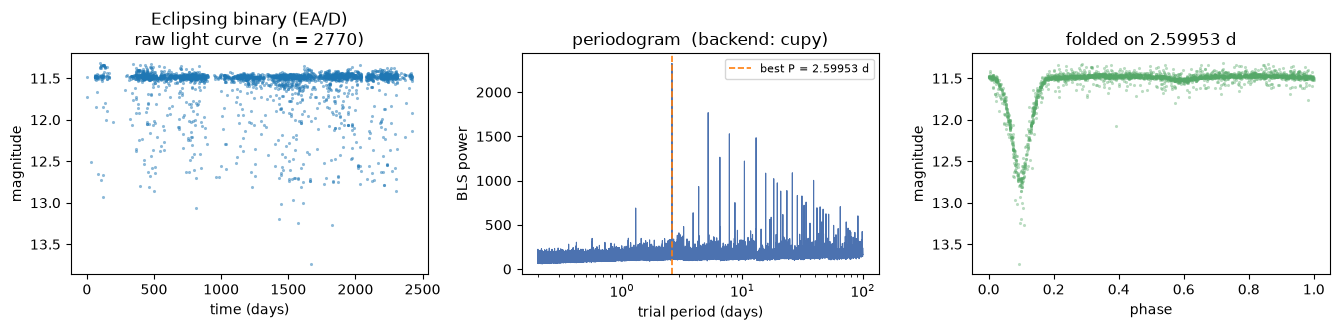

In [5]:
t, m, e, vtype, P_vsx = star(963587)
pg = cup.periodogram((t, m, e), "BLS")
peak = pg.best_periods(1, alias_diverse=True)[0]   # alias-aware peak for box searches
print(f"BLS  best period = {peak.period:.5f} d   (VSX: {P_vsx:.5f} d, type {vtype})")
depth_frac = peak.extra['depth'] / np.median(10.0 ** (-0.4 * m))   # depth is in flux units
print(f"     transit depth = {depth_frac:.2%} of the flux level,  duration = {peak.extra['duration']:.3f} d")
print(f"GLS  best period = {cup.periodogram((t, m, e), 'GLS').best_period():.5f} d  <- half the orbit!")
show(t, m, pg, title=f"Eclipsing binary ({vtype})", period=peak.period)

## 4. A long-period variable — PDM

A **Mira** pulsates over hundreds of days with a large, slightly irregular amplitude.
**PDM** (phase dispersion minimization) makes no assumption about the waveform — it bins
the folded curve and *minimizes* the scatter, so its periodogram is best **where it dips**.
Long periods need a long baseline: this star spans ~8 cycles.

PDM best period = 296.50 d   (VSX: 294.00 d, type M|SR)


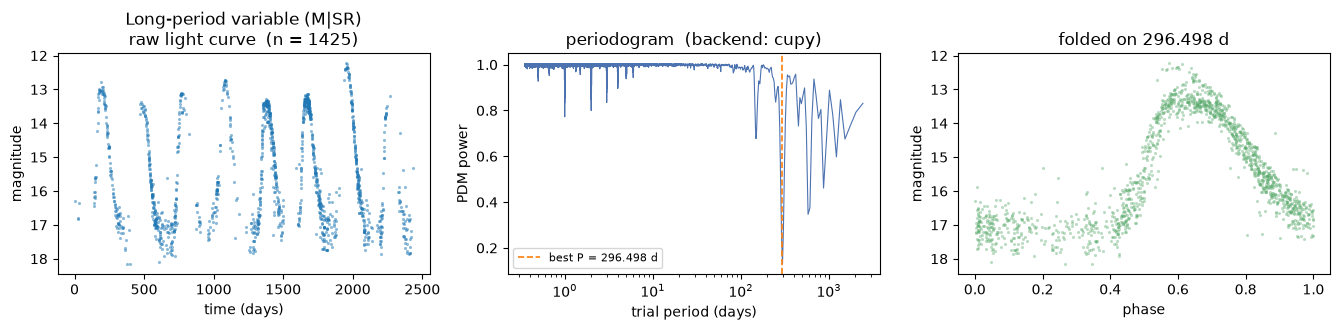

In [6]:
t, m, e, vtype, P_vsx = star(17181148958)
pg = cup.periodogram((t, m, e), "PDM")
print(f"PDM best period = {pg.best_period():.2f} d   (VSX: {P_vsx:.2f} d, type {vtype})")
show(t, m, pg, title=f"Long-period variable ({vtype})")

## 5. An exoplanet transit — TLS

For a *planet* transit, **TLS** (Transit Least Squares) matches a physically realistic,
limb-darkened transit template — more sensitive than a plain box. Here is the confirmed
hot Jupiter around **KIC 7532973** (Kepler), a clean ~1% transit every 2.14 days. Watch the
periodogram spike and the folded transit emerge.

TLS best period = 2.144604 d   (known KOI period: 2.144632 d)


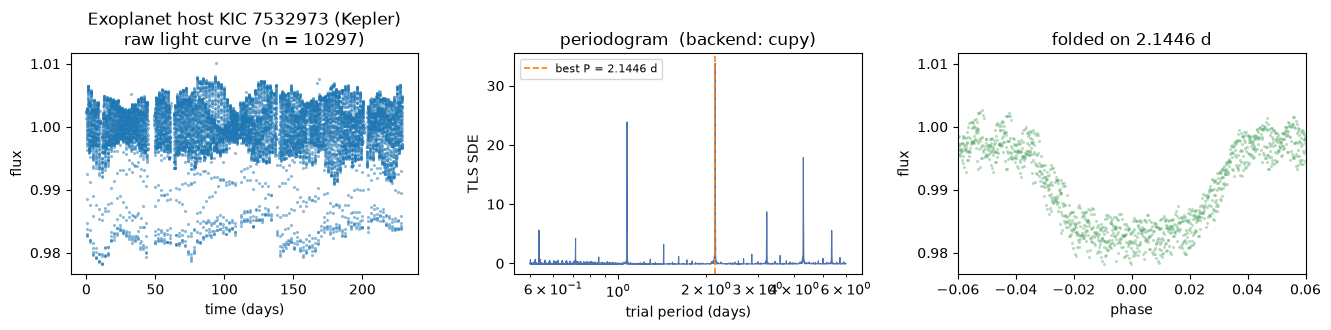

In [7]:
kep = pd.read_csv(DATA / "kepler_KIC7532973.csv")
t, f, fe = kep.time.values, kep.flux.values, kep.flux_err.values

pg = cup.periodogram((t, f, fe), "TLS", domain="flux",
                     settings=cup.TLSSettings(min_period_days=0.5, max_period_days=6.0))
print(f"TLS best period = {pg.best_period():.6f} d   (known KOI period: 2.144632 d)")
# fold on the known mid-transit time so the transit sits at phase 0
show(t, f, pg, title="Exoplanet host KIC 7532973 (Kepler)",
     flux=True, t0=133.984128, window=0.06)

## 6. Comparing methods and reading the results

Run several methods at once and you get a `MultiResult` keyed by method name. Overlaying
the (normalized) periodograms makes the eclipsing-binary lesson from §3 vivid: **GLS peaks
at P/2 while every fold/box method peaks at the true P**.

best period by method   (true orbital period = 2.5996 d):
  GLS              1.2997 d  <- half the orbit (two eclipses per cycle)
  BLS              2.5995 d
  PDM              2.5997 d
  CE               2.5997 d
  STRINGLENGTH     2.5997 d


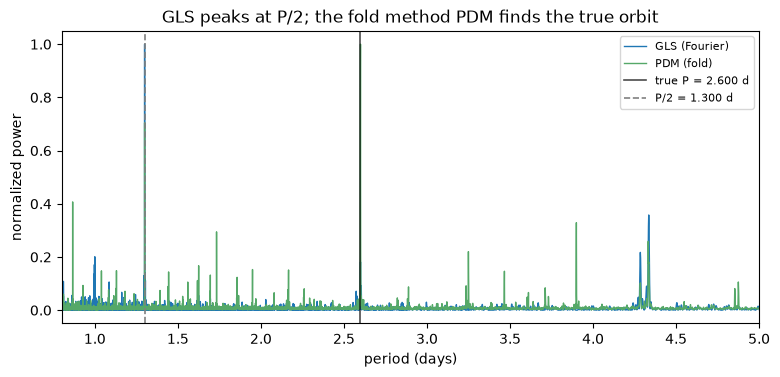

In [8]:
t, m, e, vtype, P_vsx = star(963587)   # the eclipsing binary again
res = cup.periodogram((t, m, e), ["GLS", "BLS", "PDM", "CE", "String-Length"])

print(f"best period by method   (true orbital period = {P_vsx:.4f} d):")
for name, pg in res.items():
    flag = "  <- half the orbit (two eclipses per cycle)" if name == "GLS" else ""
    print(f"  {name:14s} {pg.best_period():8.4f} d{flag}")

def norm(pg):  # normalize to [0, 1]; flip minimized statistics so peaks point up
    pw = pg.power.astype(float)
    pw = (pw - pw.min()) / (pw.max() - pw.min() + 1e-12)
    return 1.0 - pw if pg.objective_sense == "min" else pw

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(res["GLS"].period, norm(res["GLS"]), lw=1.0, color="#1f77b4", label="GLS (Fourier)")
ax.plot(res["PDM"].period, norm(res["PDM"]), lw=1.0, color="#55a868", label="PDM (fold)")
ax.axvline(P_vsx, color="k", lw=1.2, alpha=.7, label=f"true P = {P_vsx:.3f} d")
ax.axvline(P_vsx / 2, color="0.5", ls="--", lw=1.2, label=f"P/2 = {P_vsx/2:.3f} d")
ax.set(xlim=(0.8, 5.0), xlabel="period (days)", ylabel="normalized power",
       title="GLS peaks at P/2; the fold method PDM finds the true orbit")
ax.legend(fontsize=8); plt.show()

Each `Periodogram` exposes the ranked **N best periods** and, per method, extra quantities
at each peak (a false-alarm probability for GLS; depth/duration for BLS). Use
`alias_diverse=True` to skip harmonics and aliases of a peak already chosen.

In [9]:
pg = cup.periodogram((t, m, e), "GLS")
print("Top 5 GLS peaks (alias-diverse):")
for pk in pg.best_periods(5, alias_diverse=True):
    print(f"  rank {pk.rank}:  P = {pk.period:8.4f} d   power = {pk.power:.3f}"
          f"   FAP = {pk.extra.get('fap'):.2e}")

# Raw spectrum and metadata are right there for your own analysis:
print(f"\ngrid: {pg.size} trial periods from {pg.period.min():.3f} to {pg.period.max():.0f} d")
print(f"objective: {pg.objective_sense}   baseline: {pg.baseline:.0f} d   "
      f"backend: {pg.backend}")

Top 5 GLS peaks (alias-diverse):
  rank 1:  P =   1.2997 d   power = 0.084   FAP = 2.13e-48
  rank 2:  P =   4.3354 d   power = 0.030   FAP = 2.25e-14
  rank 3:  P =   0.5652 d   power = 0.029   FAP = 9.33e-14
  rank 4:  P =   0.4993 d   power = 0.024   FAP = 1.66e-10
  rank 5:  P = 2017.4030 d   power = 0.019   FAP = 7.58e-08

grid: 34621 trial periods from 0.350 to 2421 d
objective: max   baseline: 2421 d   backend: cufinufft


## 7. Multi-band search: when no single band is enough

Rubin/LSST will not hand you one dense light curve per star — it hands you six sparse ones.
Early in the survey a faint RR Lyrae may have only ~60 visits *in total*, split across
*ugrizy* over a three-year window, so no single band is solvable on its own. But they are
all the **same star with the same period**, and a multi-band search is what spends that
fact: one period, fitted jointly, with each band keeping its own mean magnitude.

The star below is **synthetic** — the one deliberately simulated object in this notebook,
because to watch a search *fail* we have to know the true answer. Its cadence follows
`benchmarks/multiband_recovery.py`: WFD-like epoch shares (*r*/*i* deepest), an RRab-like
sine plus a 0.35-amplitude second harmonic, per-band amplitudes and mean magnitudes, and
0.20 mag of noise on every point.

In [10]:
rng = np.random.default_rng(8)

P_TRUE, SPAN, N_EPOCHS, NOISE = 0.5537, 3 * 365.25, 60, 0.20   # d, d, epochs, mag
SHARE = {"u": .06, "g": .09, "r": .26, "i": .26, "z": .17, "y": .16}  # WFD epoch shares
AMP   = {"u": 1.05, "g": 1.0, "r": .72, "i": .57, "z": .53, "y": .48}  # amplitude scale
MEAN  = {"u": 23.4, "g": 22.8, "r": 22.5, "i": 22.4, "z": 22.4, "y": 22.3}  # mean mags

bands = {}
for b, share in SHARE.items():
    n = max(3, round(N_EPOCHS * share))
    t = np.sort(rng.integers(0, SPAN, n) + rng.uniform(0.05, 0.45, n))   # random nights
    ph = 2 * np.pi * t / P_TRUE
    y = 0.7 * AMP[b] * (np.sin(ph) + 0.35 * np.sin(2 * ph))    # RRab: sine + harmonic
    bands[b] = cup.LightCurve.from_arrays(t, MEAN[b] + y + rng.normal(0, NOISE, n),
                                          np.full(n, NOISE))

mb = cup.MultiBandLightCurve.from_light_curves(bands)
print(f"{mb.n_bands} bands, {sum(lc.n for lc in mb.bands.values())} epochs over "
      f"{SPAN:.0f} days:   " + "  ".join(f"{b}={lc.n}" for b, lc in mb.bands.items()))

6 bands, 61 epochs over 1096 days:   u=4  g=5  r=16  i=16  z=10  y=10


### One band first — and mind the top of the grid

*r* is one of the two deepest bands, with 16 of the 61 epochs. One setting is *not* optional
here: left to itself GLS stops at the pseudo-Nyquist frequency `nyquist_factor × 0.5 × N/T`,
which for 16 points spread over three years is **0.04 cycles/day** — it would never look
below a 27-day period. Sparse survey data always needs `maximum_frequency` stated
explicitly.

The joint search is then one extra object: `MultiBandLightCurve.from_light_curves`, handed
to the same `cup.periodogram`. Its default `mb_model="offsets"` is the shared-phase model of
VanderPlas & Ivezić (2015) — one sinusoid for the star, one constant per band. We draw the
spectra against *frequency* here, because that is where sampling aliases live: one cycle per
day apart.

true period     0.55370 d
r band alone    0.43547 d   <- wrong by 21%
all six bands   0.55372 d   <- right to 0.004%    ('offsets' model over ugrizy)


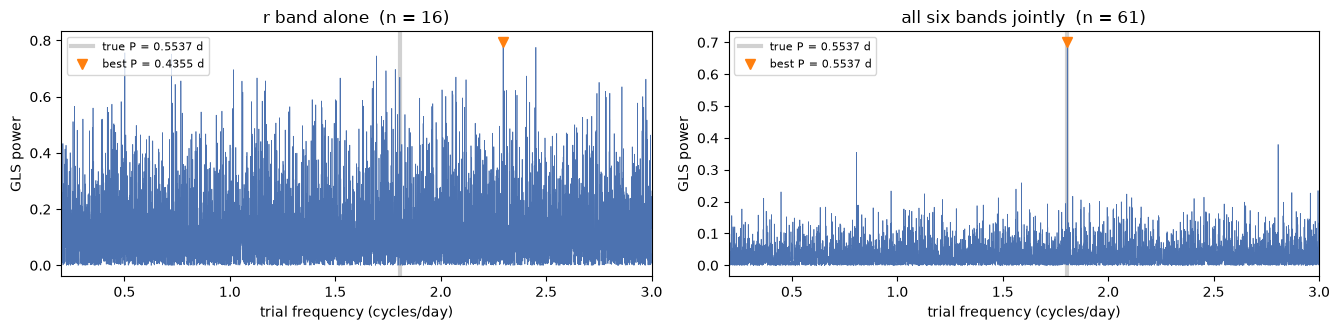

In [11]:
settings = cup.GLSSettings(maximum_frequency=3.0)        # search down to P = 0.33 d

pg_r = cup.periodogram(bands["r"], "GLS", settings=settings)   # one deep band, alone
pg = cup.periodogram(mb, "GLS", settings=settings)             # all six bands jointly

print(f"true period     {P_TRUE:.5f} d")
print(f"r band alone    {pg_r.best_period():.5f} d   <- wrong by "
      f"{abs(pg_r.best_period() / P_TRUE - 1) * 100:.0f}%")
print(f"all six bands   {pg.best_period():.5f} d   <- right to "
      f"{abs(pg.best_period() / P_TRUE - 1) * 100:.3f}%    "
      f"('{pg.meta['mb_model']}' model over {''.join(pg.meta['bands'])})")

titles = [f"r band alone  (n = {bands['r'].n})",
          f"all six bands jointly  (n = {pg.n_samples})"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.4))
for ax, p, title in zip(axes, [pg_r, pg], titles, strict=True):
    pk = p.best_periods(1)[0]
    ax.axvline(1 / P_TRUE, color="k", lw=3, alpha=.18, zorder=0,
               label=f"true P = {P_TRUE} d")
    ax.plot(p.frequency, p.power, lw=.5, color="#4c72b0", zorder=2)
    ax.plot(pk.frequency, pk.power, "v", color="C1", ms=7, zorder=3,
            label=f"best P = {pk.period:.4f} d")
    ax.set(xlim=(0.2, 3.0), xlabel="trial frequency (cycles/day)",
           ylabel="GLS power", title=title)
    ax.legend(loc="upper left", fontsize=8)
fig.tight_layout(); plt.show()

### Is that peak real, and is it the right one?

`mb_fap_bootstrap` resamples each band's `(value, error)` pairs in place — every observation
*time* held fixed, so the window function survives — and reads the peak's false-alarm
probability off the null distribution of the maximum. astropy's `LombScargleMultiband`
offers no FAP at all; here the peak lands on the `1/(n+1)` floor, meaning not one resample
came near it.

`cup.alias_diagnostics` then measures the spectral window of these six stacked cadences and
scores every frequency the sampling could confuse with the peak. A `clean` verdict means no
non-harmonic competitor gets close — the ±1 cycle/day daily aliases show up in the table,
comfortably beaten.

Folding all six bands on the recovered period closes the loop. Subtracting each band's own
mean is exactly what the `offsets` model profiles out, and it drops six sparse curves onto
one RRab shape.

peak power 0.700   bootstrap FAP = 0.0050   (floor for 200 resamples: 0.0050)
null-max levels:  10% = 0.345, 1% = 0.393

Alias check: f = 1.8059613 c/d (P = 0.55372174 d), statistic 0.699628
  Rayleigh 1/T = 0.0009352 c/d; verdict: clean - no non-harmonic competitor reaches 0.70
  window peaks: 1.00006 c/d (1.00), 0.591169 c/d (0.57), 2.09766 c/d (0.51), 3.29254 c/d (0.48), 1.56962 c/d (0.47)
   score    predicted      matched   sep/R  relation
    0.54      2.80602      2.80611    0.10  solar-day-alias m=+1 (f_w=1.0001/d)
    0.51     0.805902     0.805996    0.10  solar-day-alias m=-1 (f_w=1.0001/d)
    0.30      1.21479       1.2147    0.10  window-alias m=-1 (f_w=0.59117/d)


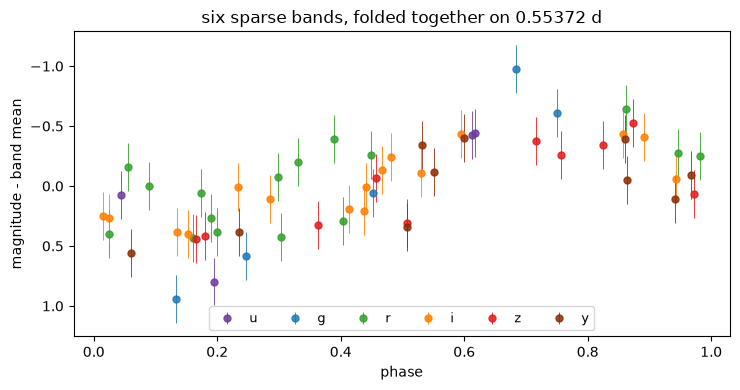

In [12]:
pg = cup.periodogram(mb, "GLS", settings=cup.GLSSettings(
    maximum_frequency=3.0, mb_fap_bootstrap=200, mb_fap_seed=0))
top = pg.best_periods(1)[0]
print(f"peak power {top.power:.3f}   bootstrap FAP = {top.extra['fap']:.4f}"
      f"   (floor for {pg.meta['fap_n_bootstrap']} resamples: "
      f"{1 / (pg.meta['fap_n_bootstrap'] + 1):.4f})")
print(f"null-max levels:  10% = {pg.meta['fap_level_10pct']:.3f}, "
      f"1% = {pg.meta['fap_level_1pct']:.3f}\n")
print(cup.alias_diagnostics(pg, data=mb).summary(max_rows=3))

COLOR = {"u": "#6a3d9a", "g": "#1f78b4", "r": "#33a02c",
         "i": "#ff7f00", "z": "#e31a1c", "y": "#8c2d04"}
fig, ax = plt.subplots(figsize=(7.5, 4.0))
for b, lc in mb.bands.items():   # subtracting each band's mean is what "offsets" fits
    ax.errorbar((lc.time / top.period) % 1.0, lc.value - lc.value.mean(), lc.error,
                fmt="o", ms=5, lw=.7, alpha=.85, color=COLOR[b], label=b)
ax.invert_yaxis()
ax.set(xlabel="phase", ylabel="magnitude - band mean",
       title=f"six sparse bands, folded together on {top.period:.5f} d")
ax.legend(ncol=6, fontsize=9, loc="lower center")
fig.tight_layout(); plt.show()

## Where to go next

- **Backends** — everything above used `backend="auto"`, which runs on your **GPU** when
  one is available and the CPU otherwise. Force a path with `backend="cpu"` / `"gpu"`.
- **Scale up** — `cup.batch_periodograms("lightcurves/*.parquet", "GLS", sink="out/")`
  runs over thousands-to-millions of light curves on a CPU pool or the GPU.
- **Your own data** — column names are auto-detected for the major surveys (ASAS-SN,
  ATLAS, ZTF, TESS, Kepler, Gaia, …); see the
  [light-curves guide](https://cuperiod.readthedocs.io/en/latest/guide/light-curves.html).
- **Full docs:** <https://cuperiod.readthedocs.io>